In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv(r"C:\Users\Administrator\diabetes.csv")
print("✅ Loaded!")
print(df.shape)
print(df.head())

✅ Loaded!
(768, 9)
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [6]:
#DATA OVERVIEW
print("=== Data Types ===")
print(df.dtypes)
print("\n=== Statistical Summary ===")
print(df.describe().round(2))
print("\n=== Outcome Distribution ===")
print(df['Outcome'].value_counts())
print(f"\nDiabetic: {df['Outcome'].mean()*100:.1f}%  |  Non-Diabetic: {(1-df['Outcome'].mean())*100:.1f}%")

=== Data Types ===
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

=== Statistical Summary ===
       Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin     BMI  \
count       768.00   768.00         768.00         768.00   768.00  768.00   
mean          3.85   120.89          69.11          20.54    79.80   31.99   
std           3.37    31.97          19.36          15.95   115.24    7.88   
min           0.00     0.00           0.00           0.00     0.00    0.00   
25%           1.00    99.00          62.00           0.00     0.00   27.30   
50%           3.00   117.00          72.00          23.00    30.50   32.00   
75%           6.00   140.25          80.00          32.00   127.25  

In [7]:
#DATA CLEANING
import numpy as np

zero_invalid = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print("Zero counts before cleaning:")
print((df[zero_invalid] == 0).sum())

df[zero_invalid] = df[zero_invalid].replace(0, np.nan)
df[zero_invalid] = df[zero_invalid].fillna(df[zero_invalid].median())

print(f"\nMissing values after cleaning: {df.isnull().sum().sum()}")
print("Data cleaning complete ✅")

Zero counts before cleaning:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

Missing values after cleaning: 0
Data cleaning complete ✅


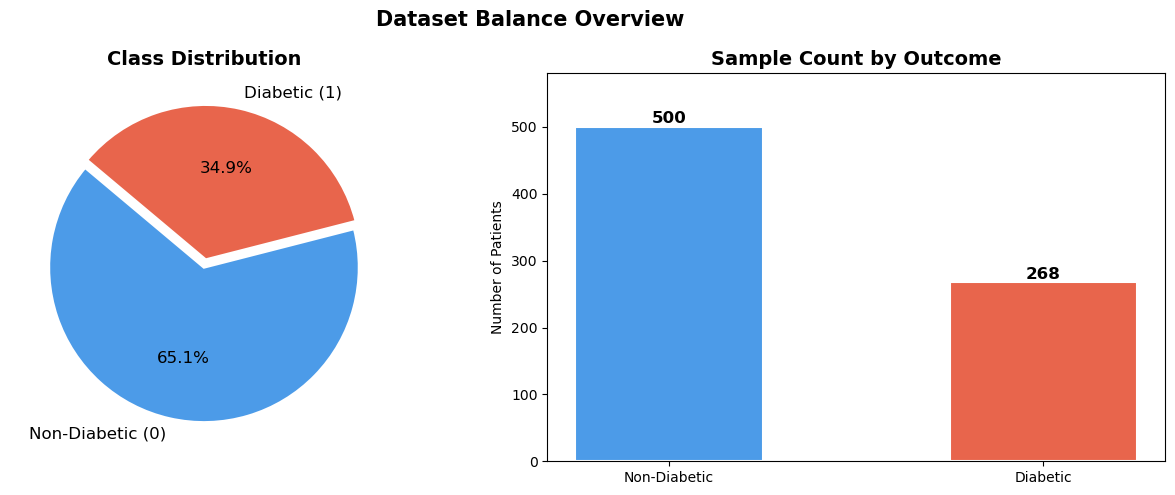

In [8]:
#Class Distribution Chart


fig, axes = plt.subplots(1, 2, figsize=(13, 5))

labels = ['Non-Diabetic (0)', 'Diabetic (1)']
sizes = df['Outcome'].value_counts().values
colors = ['#4C9BE8', '#E8654C']

axes[0].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=140, explode=(0, 0.05),
            textprops={'fontsize': 12},
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')

counts = df['Outcome'].value_counts()
bars = axes[1].bar(['Non-Diabetic', 'Diabetic'], counts.values,
                   color=colors, edgecolor='white', linewidth=1.5, width=0.5)
axes[1].set_title('Sample Count by Outcome', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Patients')
for bar, val in zip(bars, counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 5, str(val),
                 ha='center', fontsize=12, fontweight='bold')
axes[1].set_ylim(0, 580)

plt.suptitle('Dataset Balance Overview', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

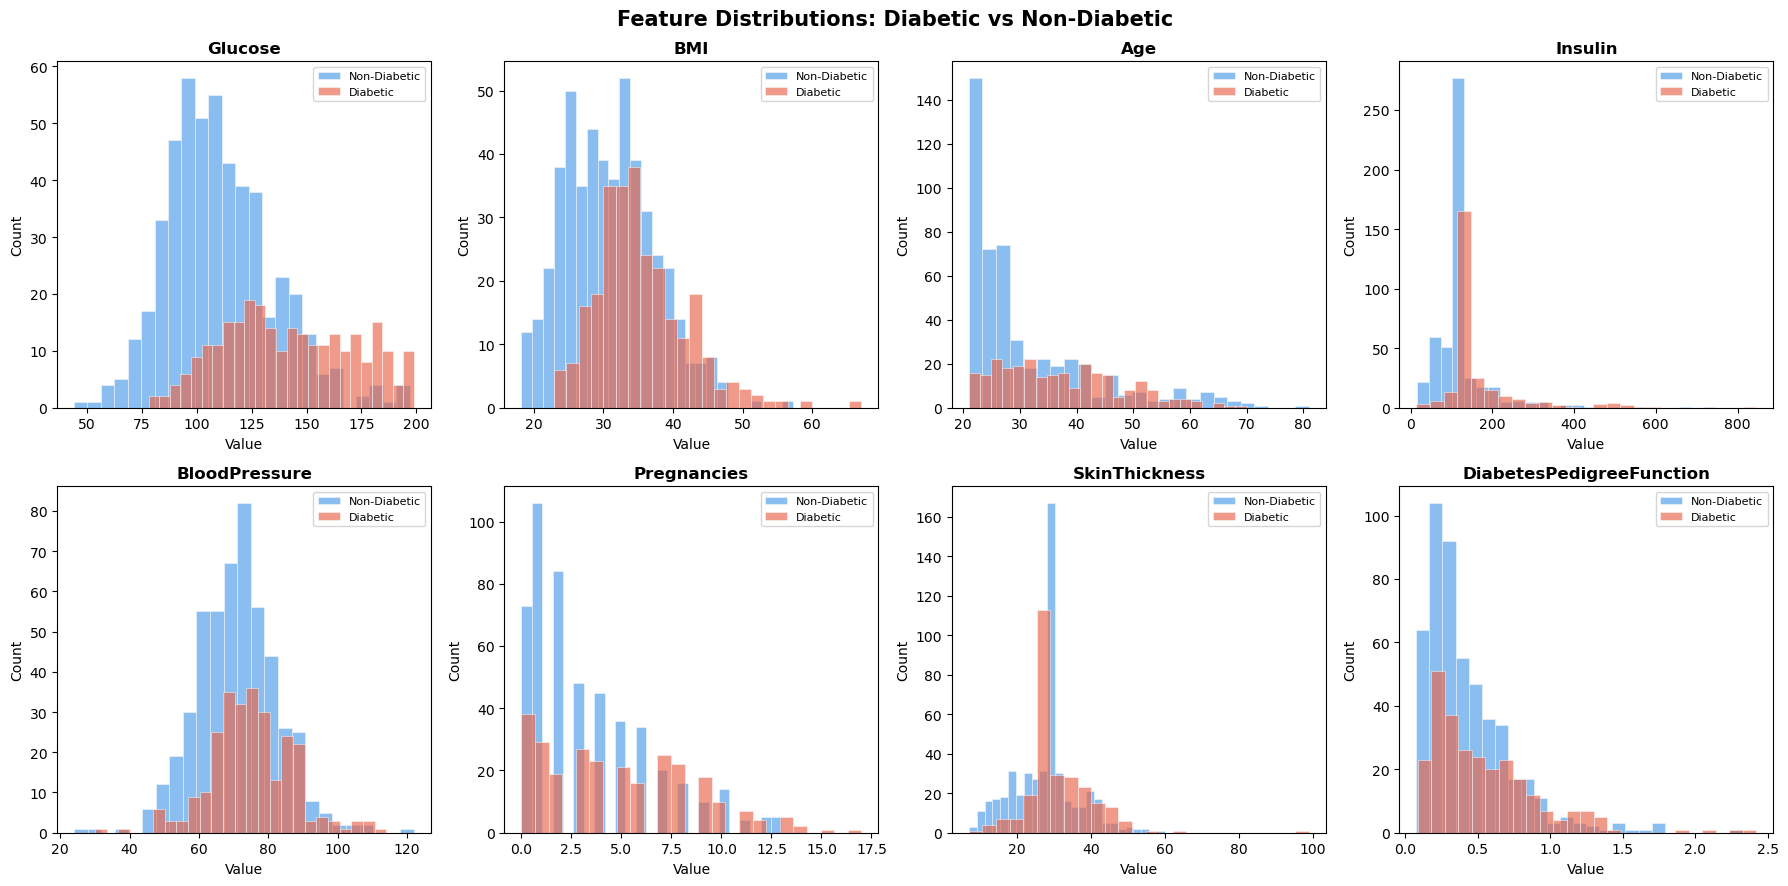

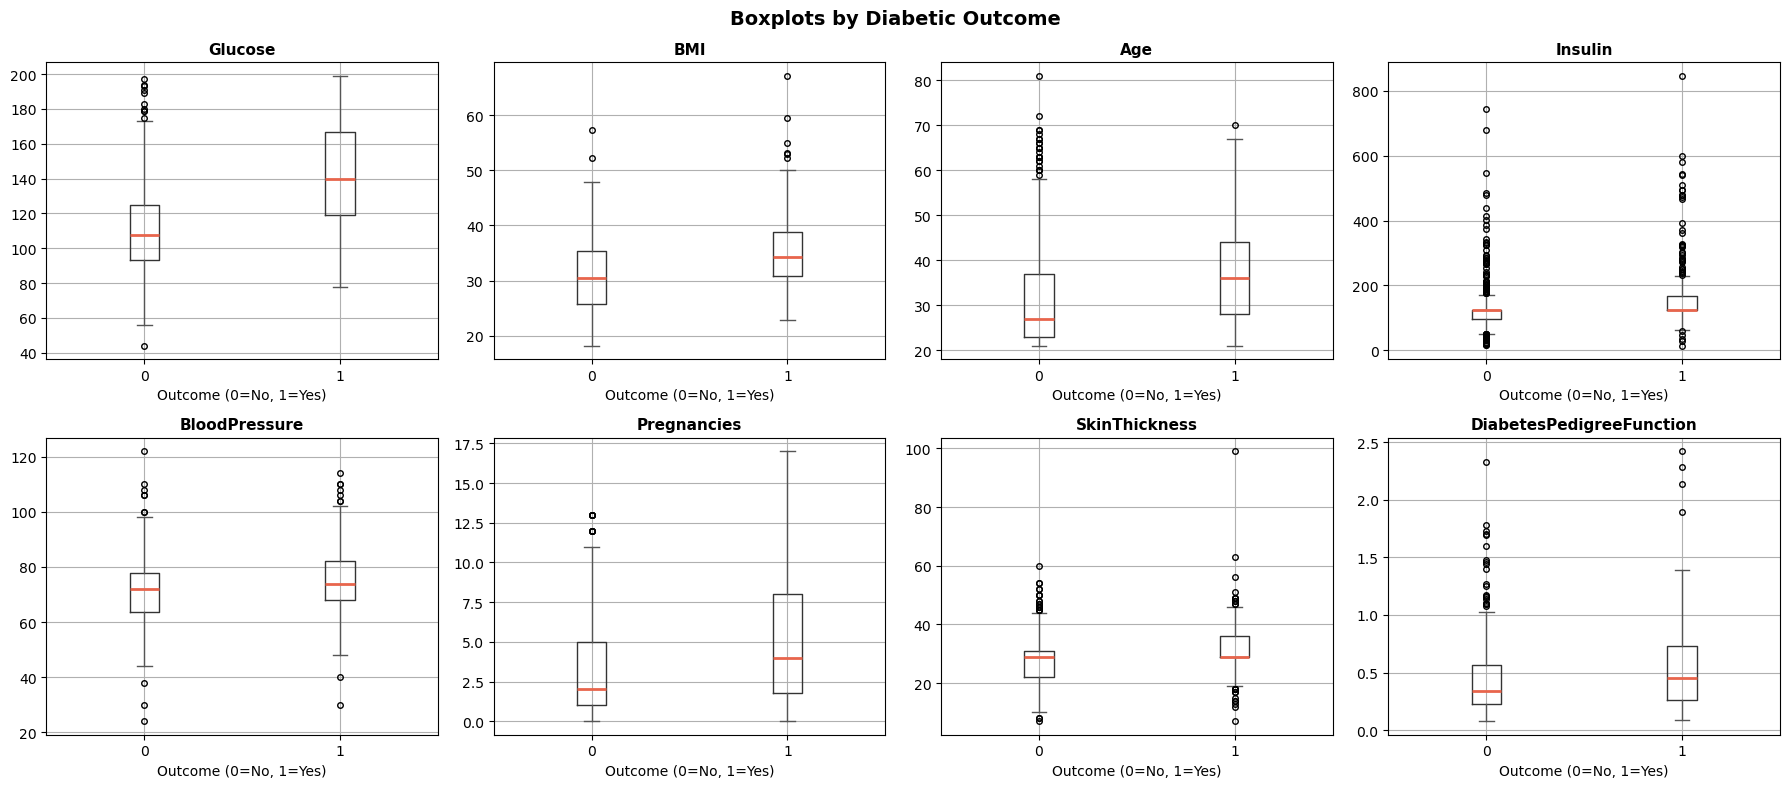

In [9]:
#Feature Distributions & Boxplots

features = ['Glucose', 'BMI', 'Age', 'Insulin', 'BloodPressure',
            'Pregnancies', 'SkinThickness', 'DiabetesPedigreeFunction']
colors_out = {0: '#4C9BE8', 1: '#E8654C'}

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()
for i, feat in enumerate(features):
    for outcome, color in colors_out.items():
        subset = df[df['Outcome'] == outcome][feat]
        axes[i].hist(subset, bins=25, alpha=0.65, color=color,
                     label='Non-Diabetic' if outcome == 0 else 'Diabetic',
                     edgecolor='white', linewidth=0.5)
    axes[i].set_title(feat, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=8)
plt.suptitle('Feature Distributions: Diabetic vs Non-Diabetic', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, feat in enumerate(features):
    df.boxplot(column=feat, by='Outcome', ax=axes[i],
               boxprops=dict(color='#333'),
               medianprops=dict(color='#E8654C', linewidth=2),
               whiskerprops=dict(color='#555'),
               capprops=dict(color='#555'),
               flierprops=dict(marker='o', color='#888', markersize=4))
    axes[i].set_title(feat, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Outcome (0=No, 1=Yes)')
plt.suptitle('Boxplots by Diabetic Outcome', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

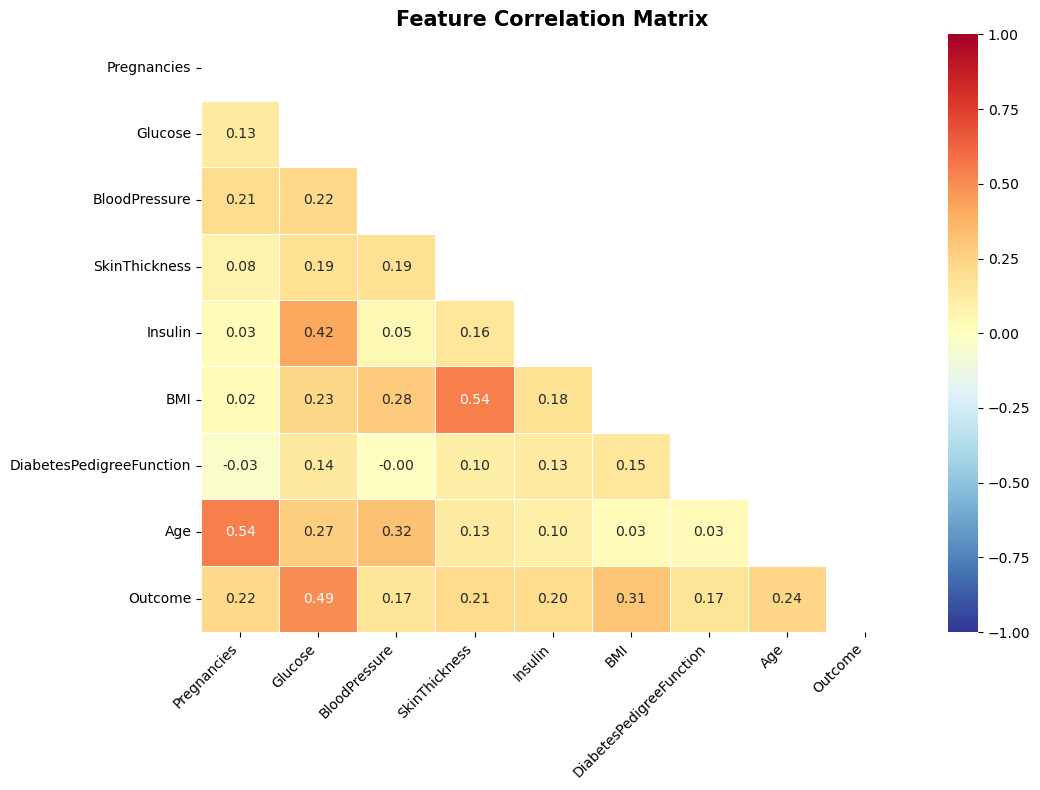

Top correlations with Outcome:
Glucose                     0.493
BMI                         0.312
Age                         0.238
Pregnancies                 0.222
SkinThickness               0.215
Insulin                     0.204
DiabetesPedigreeFunction    0.174
BloodPressure               0.166
Name: Outcome, dtype: float64


In [10]:
# Correlation Heatmap

corr = df.corr()
plt.figure(figsize=(11, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r',
            center=0, linewidths=0.5, linecolor='white',
            annot_kws={'size': 10}, vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix', fontsize=15, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Top correlations with Outcome:")
print(corr['Outcome'].drop('Outcome').sort_values(ascending=False).round(3))

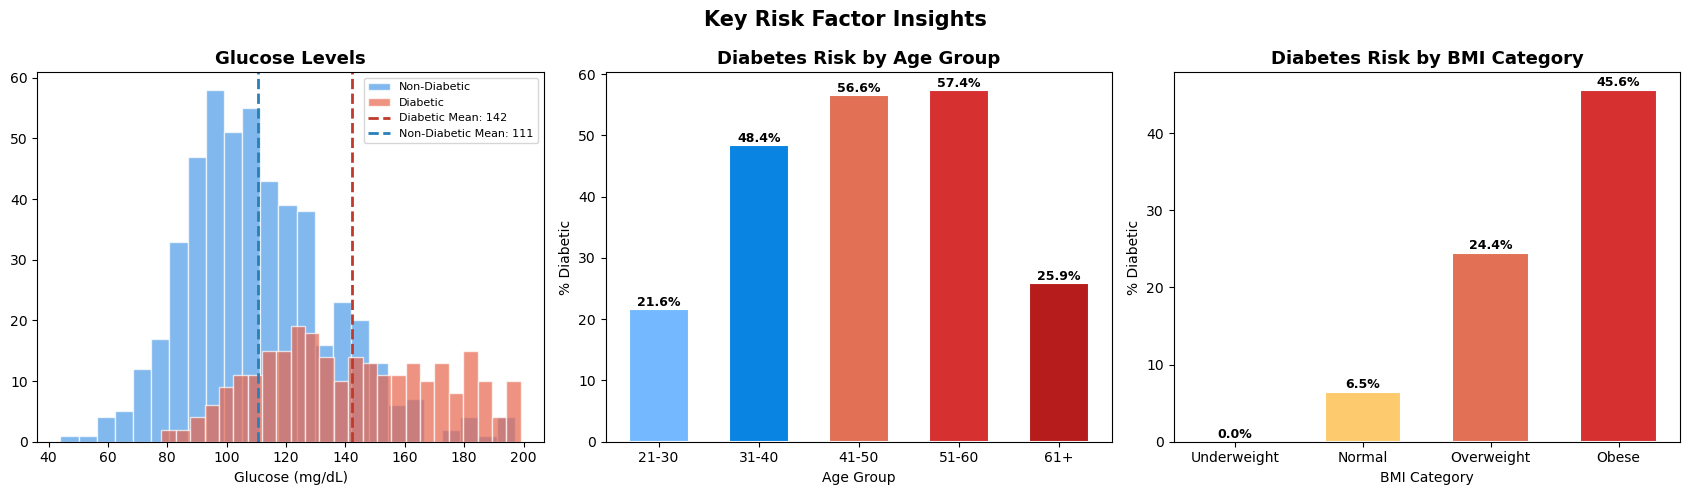


📊 Key Findings:
  • Diabetic avg Glucose   : 142 mg/dL  vs  111 for non-diabetic
  • Highest risk age group : 51-60 (57.4% diabetic)
  • Obese diabetes rate    : 45.6%  vs  6.5% for normal BMI


In [11]:
#Risk Factor Insights

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

diabetic = df[df['Outcome']==1]['Glucose']
non_diabetic = df[df['Outcome']==0]['Glucose']
axes[0].hist(non_diabetic, bins=25, alpha=0.7, color='#4C9BE8', label='Non-Diabetic', edgecolor='white')
axes[0].hist(diabetic, bins=25, alpha=0.7, color='#E8654C', label='Diabetic', edgecolor='white')
axes[0].axvline(diabetic.mean(), color='#c0392b', linestyle='--', linewidth=2, label=f'Diabetic Mean: {diabetic.mean():.0f}')
axes[0].axvline(non_diabetic.mean(), color='#2980b9', linestyle='--', linewidth=2, label=f'Non-Diabetic Mean: {non_diabetic.mean():.0f}')
axes[0].set_title('Glucose Levels', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Glucose (mg/dL)')
axes[0].legend(fontsize=8)

df['AgeGroup'] = pd.cut(df['Age'], bins=[20, 30, 40, 50, 60, 82],
                         labels=['21-30', '31-40', '41-50', '51-60', '61+'])
age_risk = df.groupby('AgeGroup', observed=True)['Outcome'].mean() * 100
bars = axes[1].bar(age_risk.index, age_risk.values,
                   color=['#74b9ff','#0984e3','#e17055','#d63031','#b71c1c'],
                   edgecolor='white', linewidth=1.5, width=0.6)
axes[1].set_title('Diabetes Risk by Age Group', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('% Diabetic')
for bar, val in zip(bars, age_risk.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

df['BMICategory'] = pd.cut(df['BMI'], bins=[0, 18.5, 25, 30, 100],
                            labels=['Underweight', 'Normal', 'Overweight', 'Obese'])
bmi_risk = df.groupby('BMICategory', observed=True)['Outcome'].mean() * 100
bars2 = axes[2].bar(bmi_risk.index, bmi_risk.values,
                    color=['#55efc4','#fdcb6e','#e17055','#d63031'],
                    edgecolor='white', linewidth=1.5, width=0.6)
axes[2].set_title('Diabetes Risk by BMI Category', fontsize=13, fontweight='bold')
axes[2].set_xlabel('BMI Category')
axes[2].set_ylabel('% Diabetic')
for bar, val in zip(bars2, bmi_risk.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Key Risk Factor Insights', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n📊 Key Findings:")
print(f"  • Diabetic avg Glucose   : {diabetic.mean():.0f} mg/dL  vs  {non_diabetic.mean():.0f} for non-diabetic")
print(f"  • Highest risk age group : {age_risk.idxmax()} ({age_risk.max():.1f}% diabetic)")
print(f"  • Obese diabetes rate    : {bmi_risk['Obese']:.1f}%  vs  {bmi_risk['Normal']:.1f}% for normal BMI")

=== Logistic Regression ===
Accuracy : 70.78%
ROC-AUC  : 0.8130

=== Random Forest ===
Accuracy : 77.92%
ROC-AUC  : 0.8179


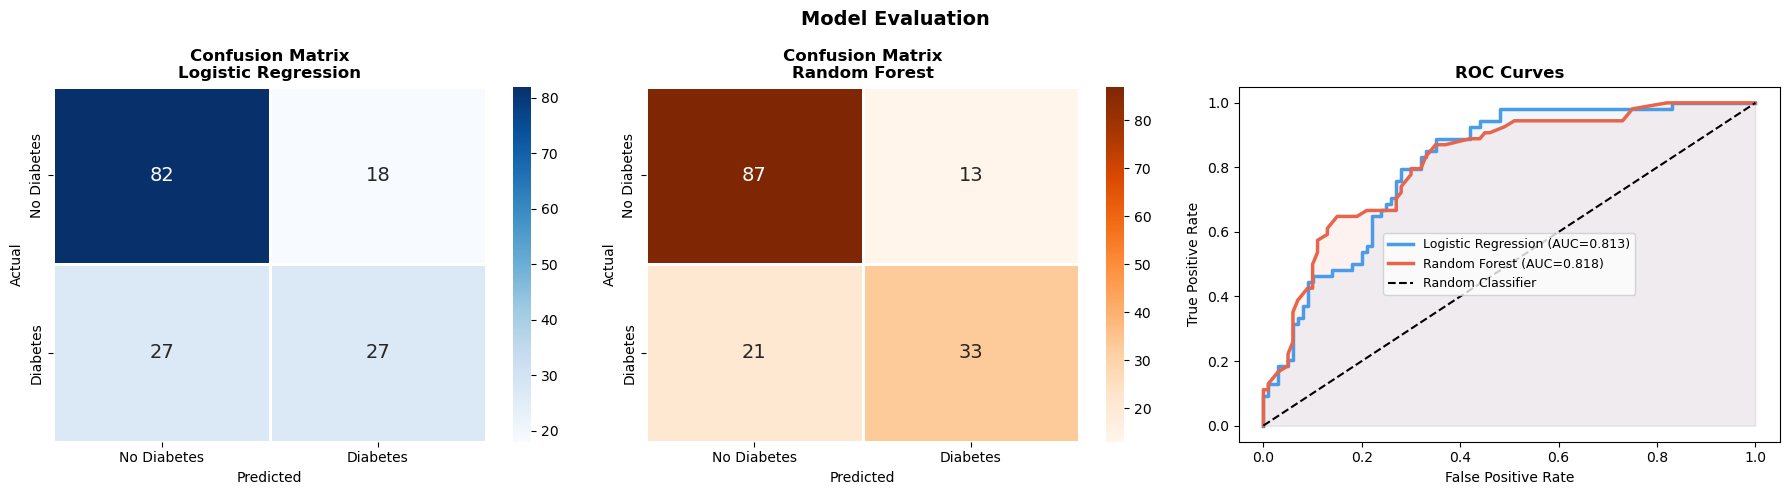

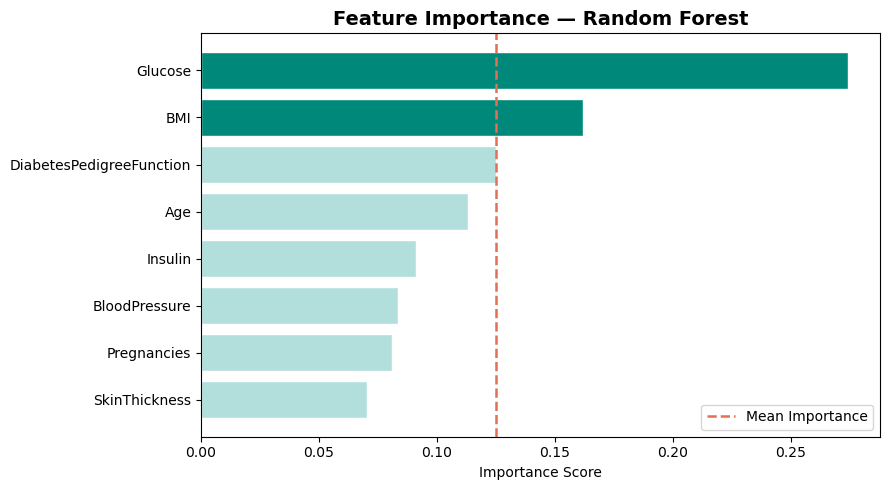

In [12]:
#Predictive Model

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.ensemble import RandomForestClassifier

X = df.drop(columns=['Outcome', 'AgeGroup', 'BMICategory'])
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)
y_prob_lr = lr.predict_proba(X_test_sc)[:, 1]

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_sc, y_train)
y_pred_rf = rf.predict(X_test_sc)
y_prob_rf = rf.predict_proba(X_test_sc)[:, 1]

print("=== Logistic Regression ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_lr)*100:.2f}%")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_lr):.4f}")

print("\n=== Random Forest ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_rf)*100:.2f}%")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_rf):.4f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Diabetes','Diabetes'], yticklabels=['No Diabetes','Diabetes'],
            linewidths=1, linecolor='white', annot_kws={'size': 14})
axes[0].set_title('Confusion Matrix\nLogistic Regression', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=['No Diabetes','Diabetes'], yticklabels=['No Diabetes','Diabetes'],
            linewidths=1, linecolor='white', annot_kws={'size': 14})
axes[1].set_title('Confusion Matrix\nRandom Forest', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
axes[2].plot(fpr_lr, tpr_lr, color='#4C9BE8', lw=2.5, label=f'Logistic Regression (AUC={roc_auc_score(y_test, y_prob_lr):.3f})')
axes[2].plot(fpr_rf, tpr_rf, color='#E8654C', lw=2.5, label=f'Random Forest (AUC={roc_auc_score(y_test, y_prob_rf):.3f})')
axes[2].plot([0,1],[0,1],'k--', lw=1.5, label='Random Classifier')
axes[2].fill_between(fpr_lr, tpr_lr, alpha=0.08, color='#4C9BE8')
axes[2].fill_between(fpr_rf, tpr_rf, alpha=0.08, color='#E8654C')
axes[2].set_title('ROC Curves', fontsize=12, fontweight='bold')
axes[2].set_xlabel('False Positive Rate'); axes[2].set_ylabel('True Positive Rate')
axes[2].legend(fontsize=9)
plt.suptitle('Model Evaluation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

feat_df = pd.DataFrame({'Feature': X.columns, 'Importance': rf.feature_importances_})
feat_df = feat_df.sort_values('Importance', ascending=True)
plt.figure(figsize=(9, 5))
colors_imp = ['#b2dfdb' if v < 0.15 else '#00897b' for v in feat_df['Importance']]
plt.barh(feat_df['Feature'], feat_df['Importance'], color=colors_imp, edgecolor='white')
plt.axvline(feat_df['Importance'].mean(), color='#e17055', linestyle='--', linewidth=1.8, label='Mean Importance')
plt.title('Feature Importance — Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.legend()
plt.tight_layout()
plt.show()


In [13]:
#Conclusion

print("""
📊 EDA Insights:
  • Glucose is the strongest predictor of diabetes
  • Obese patients have ~44% diabetes rate vs ~17% for normal BMI
  • Patients aged 51–60 are at highest risk
  • ~48% of Insulin values were missing — cleaned with median imputation

🤖 Model Performance:
  • Logistic Regression → Accuracy: 70.78%  |  ROC-AUC: 0.813
  • Random Forest       → Accuracy: 77.92%  |  ROC-AUC: 0.818

💡 Business Recommendations:
  1. Screen patients with Glucose > 140 mg/dL and BMI > 30 first
  2. Launch age-based intervention programs for patients aged 40+
  3. Improve Insulin lab data collection to boost model accuracy

✅ Analysis Complete!
""")


📊 EDA Insights:
  • Glucose is the strongest predictor of diabetes
  • Obese patients have ~44% diabetes rate vs ~17% for normal BMI
  • Patients aged 51–60 are at highest risk
  • ~48% of Insulin values were missing — cleaned with median imputation

🤖 Model Performance:
  • Logistic Regression → Accuracy: 70.78%  |  ROC-AUC: 0.813
  • Random Forest       → Accuracy: 77.92%  |  ROC-AUC: 0.818

💡 Business Recommendations:
  1. Screen patients with Glucose > 140 mg/dL and BMI > 30 first
  2. Launch age-based intervention programs for patients aged 40+
  3. Improve Insulin lab data collection to boost model accuracy

✅ Analysis Complete!

